<a href="https://colab.research.google.com/github/mahimarajesh7-netizen/fraudlens/blob/main/%20notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Verify files exist
data_path = '/content/drive/MyDrive/fraudlens/data/'
files = os.listdir(data_path)
print("Files in data folder:")
for f in files:
    size = os.path.getsize(data_path + f) / (1024*1024)
    print(f"  {f}: {size:.1f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in data folder:
  train_transaction.csv: 651.7 MB
  test_transaction.csv: 584.8 MB
  train_identity.csv: 25.3 MB


In [6]:
data_path = '/content/drive/MyDrive/fraudlens/data/'
files = os.listdir(data_path)
print("Files in data folder:")
for f in files:
    size = os.path.getsize(data_path + f) / (1024*1024)
    print(f"  {f}: {size:.1f} MB")

Files in data folder:
  train_transaction.csv: 651.7 MB
  test_transaction.csv: 584.8 MB
  train_identity.csv: 25.3 MB


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

NAVY  = '#0A1628'
GOLD  = '#C9A84C'
TEAL  = '#1A7A6E'
RED   = '#C0392B'
LIGHT = '#E8F4FD'

print("✓ Libraries loaded")

✓ Libraries loaded


In [8]:
data_path = '/content/drive/MyDrive/fraudlens/data/'

print("Loading transaction data (651MB — takes ~60 seconds)...")
df_trans = pd.read_csv(data_path + 'train_transaction.csv')
print(f"✓ Transactions: {df_trans.shape[0]:,} rows, {df_trans.shape[1]} columns")

print("\nLoading identity data...")
df_id = pd.read_csv(data_path + 'train_identity.csv')
print(f"✓ Identity: {df_id.shape[0]:,} rows, {df_id.shape[1]} columns")

Loading transaction data (651MB — takes ~60 seconds)...
✓ Transactions: 590,540 rows, 394 columns

Loading identity data...
✓ Identity: 144,233 rows, 41 columns


In [9]:
# Left join — keep all transactions, add identity where available
df = df_trans.merge(df_id, on='TransactionID', how='left')

print(f"Merged dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\n{'='*45}")
print(f"  FRAUD OVERVIEW")
print(f"{'='*45}")
print(f"  Total transactions:    {len(df):,}")
print(f"  Fraudulent:            {df['isFraud'].sum():,} ({df['isFraud'].mean()*100:.2f}%)")
print(f"  Legitimate:            {(df['isFraud']==0).sum():,} ({(1-df['isFraud'].mean())*100:.2f}%)")
print(f"  Date range (seconds):  {df['TransactionDT'].min():,} — {df['TransactionDT'].max():,}")
print(f"  Avg transaction amt:   ${df['TransactionAmt'].mean():.2f}")
print(f"  Median transaction:    ${df['TransactionAmt'].median():.2f}")
print(f"{'='*45}")

Merged dataset: 590,540 rows, 434 columns

  FRAUD OVERVIEW
  Total transactions:    590,540
  Fraudulent:            20,663 (3.50%)
  Legitimate:            569,877 (96.50%)
  Date range (seconds):  86,400 — 15,811,131
  Avg transaction amt:   $135.03
  Median transaction:    $68.77


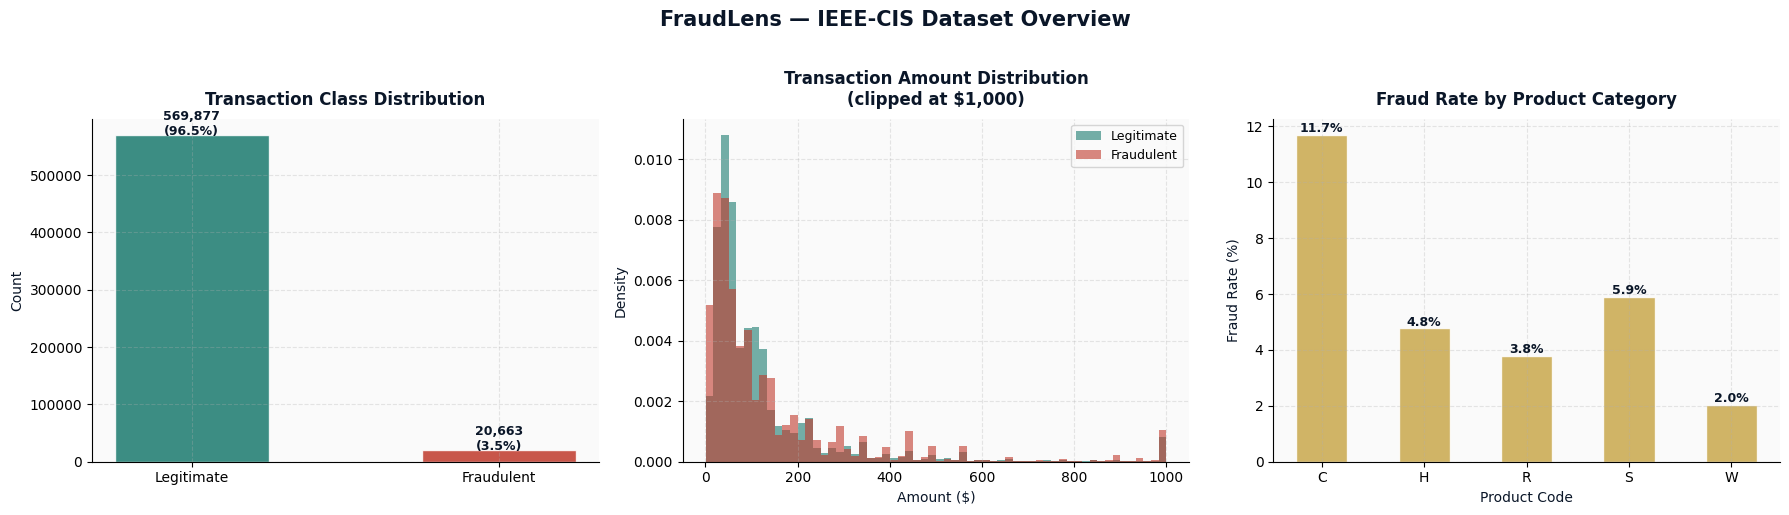

✓ Chart saved


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FraudLens — IEEE-CIS Dataset Overview',
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)

# Chart 1 — Class distribution
fraud_counts = df['isFraud'].value_counts()
bars = axes[0].bar(['Legitimate', 'Fraudulent'],
                   fraud_counts.values,
                   color=[TEAL, RED], alpha=0.85,
                   edgecolor='white', width=0.5)
axes[0].set_title('Transaction Class Distribution',
                  color=NAVY, fontweight='bold', pad=10)
axes[0].set_ylabel('Count', color=NAVY)
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 500,
                f'{val:,}\n({val/len(df)*100:.1f}%)',
                ha='center', fontsize=9,
                color=NAVY, fontweight='bold')

# Chart 2 — Transaction amount distribution
df_legit_amt = df[df['isFraud']==0]['TransactionAmt'].clip(0, 1000)
df_fraud_amt = df[df['isFraud']==1]['TransactionAmt'].clip(0, 1000)

axes[1].hist(df_legit_amt, bins=60, alpha=0.6,
             color=TEAL, label='Legitimate', density=True)
axes[1].hist(df_fraud_amt, bins=60, alpha=0.6,
             color=RED, label='Fraudulent', density=True)
axes[1].set_title('Transaction Amount Distribution\n(clipped at $1,000)',
                  color=NAVY, fontweight='bold', pad=10)
axes[1].set_xlabel('Amount ($)', color=NAVY)
axes[1].set_ylabel('Density', color=NAVY)
axes[1].legend(fontsize=9)

# Chart 3 — Fraud rate by product code
product_fraud = df.groupby('ProductCD')['isFraud'].agg(
    fraud_rate='mean', count='count').reset_index()
product_fraud['fraud_rate'] *= 100

bars3 = axes[2].bar(product_fraud['ProductCD'],
                    product_fraud['fraud_rate'],
                    color=GOLD, alpha=0.85,
                    edgecolor='white', width=0.5)
axes[2].set_title('Fraud Rate by Product Category',
                  color=NAVY, fontweight='bold', pad=10)
axes[2].set_xlabel('Product Code', color=NAVY)
axes[2].set_ylabel('Fraud Rate (%)', color=NAVY)
for bar, val in zip(bars3, product_fraud['fraud_rate']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.1f}%',
                ha='center', fontsize=9,
                fontweight='bold', color=NAVY)

plt.tight_layout()
plt.savefig('/content/01_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

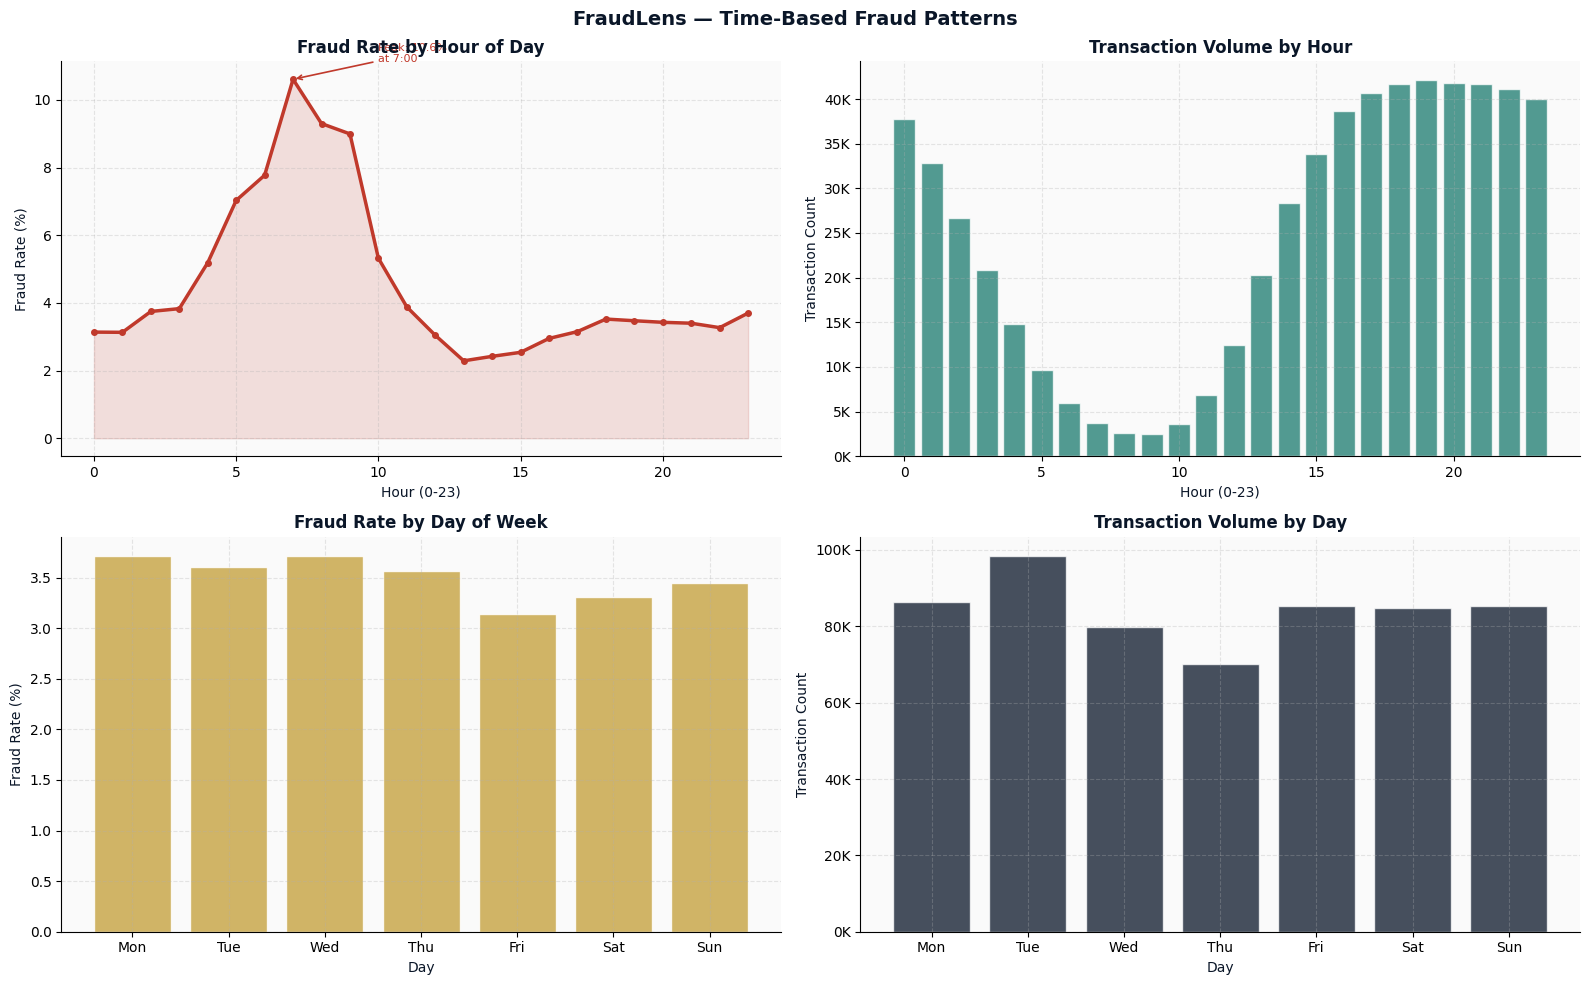


Key findings:
Peak fraud hour: 7:00 (10.6% fraud rate)
Lowest fraud hour: 13:00


In [11]:
# Convert TransactionDT to hour of day and day of week
df['hour'] = (df['TransactionDT'] / 3600).astype(int) % 24
df['day']  = (df['TransactionDT'] / (3600*24)).astype(int) % 7

hourly = df.groupby('hour')['isFraud'].agg(
    fraud_rate='mean', count='count').reset_index()
hourly['fraud_rate'] *= 100

daily = df.groupby('day')['isFraud'].agg(
    fraud_rate='mean', count='count').reset_index()
daily['fraud_rate'] *= 100
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily['day_name'] = daily['day'].map(lambda x: day_names[x])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('FraudLens — Time-Based Fraud Patterns',
             fontsize=14, fontweight='bold', color=NAVY)

# Fraud rate by hour
axes[0,0].plot(hourly['hour'], hourly['fraud_rate'],
               color=RED, linewidth=2.5,
               marker='o', markersize=4)
axes[0,0].fill_between(hourly['hour'], hourly['fraud_rate'],
                        alpha=0.15, color=RED)
axes[0,0].set_title('Fraud Rate by Hour of Day',
                     color=NAVY, fontweight='bold')
axes[0,0].set_xlabel('Hour (0-23)', color=NAVY)
axes[0,0].set_ylabel('Fraud Rate (%)', color=NAVY)
peak_hour = hourly.loc[hourly['fraud_rate'].idxmax()]
axes[0,0].annotate(f"Peak: {peak_hour['fraud_rate']:.1f}%\nat {int(peak_hour['hour'])}:00",
                   xy=(peak_hour['hour'], peak_hour['fraud_rate']),
                   xytext=(peak_hour['hour']+3, peak_hour['fraud_rate']+0.5),
                   fontsize=8, color=RED,
                   arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

# Volume by hour
axes[0,1].bar(hourly['hour'], hourly['count'],
              color=TEAL, alpha=0.75, edgecolor='white')
axes[0,1].set_title('Transaction Volume by Hour',
                     color=NAVY, fontweight='bold')
axes[0,1].set_xlabel('Hour (0-23)', color=NAVY)
axes[0,1].set_ylabel('Transaction Count', color=NAVY)
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Fraud rate by day
axes[1,0].bar(daily['day_name'], daily['fraud_rate'],
              color=GOLD, alpha=0.85, edgecolor='white')
axes[1,0].set_title('Fraud Rate by Day of Week',
                     color=NAVY, fontweight='bold')
axes[1,0].set_xlabel('Day', color=NAVY)
axes[1,0].set_ylabel('Fraud Rate (%)', color=NAVY)

# Volume by day
axes[1,1].bar(daily['day_name'], daily['count'],
              color=NAVY, alpha=0.75, edgecolor='white')
axes[1,1].set_title('Transaction Volume by Day',
                     color=NAVY, fontweight='bold')
axes[1,1].set_xlabel('Day', color=NAVY)
axes[1,1].set_ylabel('Transaction Count', color=NAVY)
axes[1,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('/content/02_time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey findings:")
print(f"Peak fraud hour: {int(peak_hour['hour'])}:00 ({peak_hour['fraud_rate']:.1f}% fraud rate)")
print(f"Lowest fraud hour: {int(hourly.loc[hourly['fraud_rate'].idxmin(), 'hour'])}:00")

Total columns: 436
Columns with NO missing values: 54
Columns with >80% missing: 74
Columns with >50% missing: 214


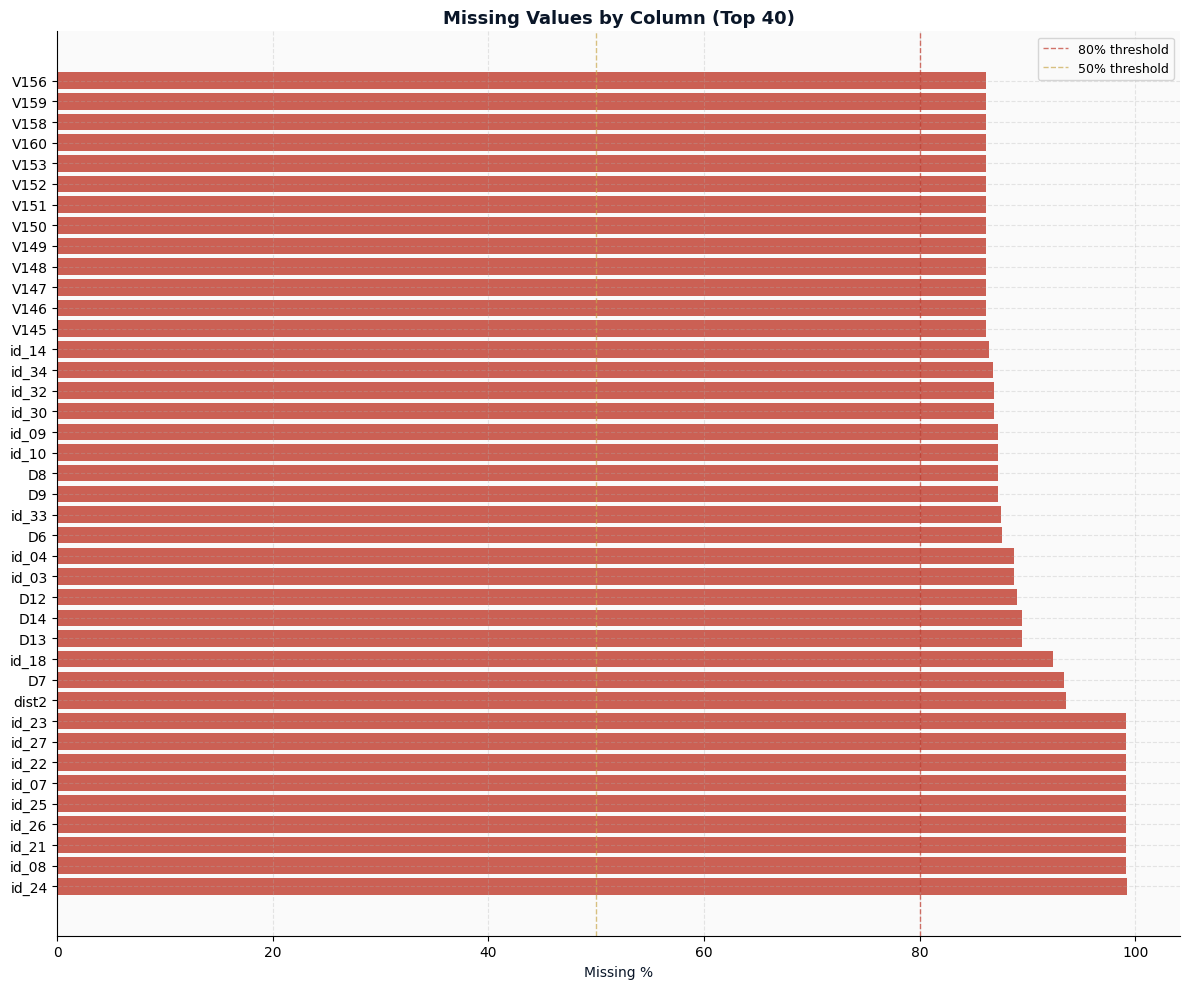

✓ Chart saved


In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(f"Total columns: {len(df.columns)}")
print(f"Columns with NO missing values: {(missing_df['missing_pct']==0).sum()}")
print(f"Columns with >80% missing: {(missing_df['missing_pct']>80).sum()}")
print(f"Columns with >50% missing: {(missing_df['missing_pct']>50).sum()}")

# Visualise top 40 missing
fig, ax = plt.subplots(figsize=(12, 10))
top_missing = missing_df[missing_df['missing_pct'] > 0].head(40)
colors = [RED if p > 80 else GOLD if p > 50 else TEAL
          for p in top_missing['missing_pct']]
ax.barh(top_missing.index, top_missing['missing_pct'],
        color=colors, alpha=0.8)
ax.axvline(x=80, color=RED, linestyle='--',
           linewidth=1, alpha=0.7, label='80% threshold')
ax.axvline(x=50, color=GOLD, linestyle='--',
           linewidth=1, alpha=0.7, label='50% threshold')
ax.set_title('Missing Values by Column (Top 40)',
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Missing %', color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/content/03_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

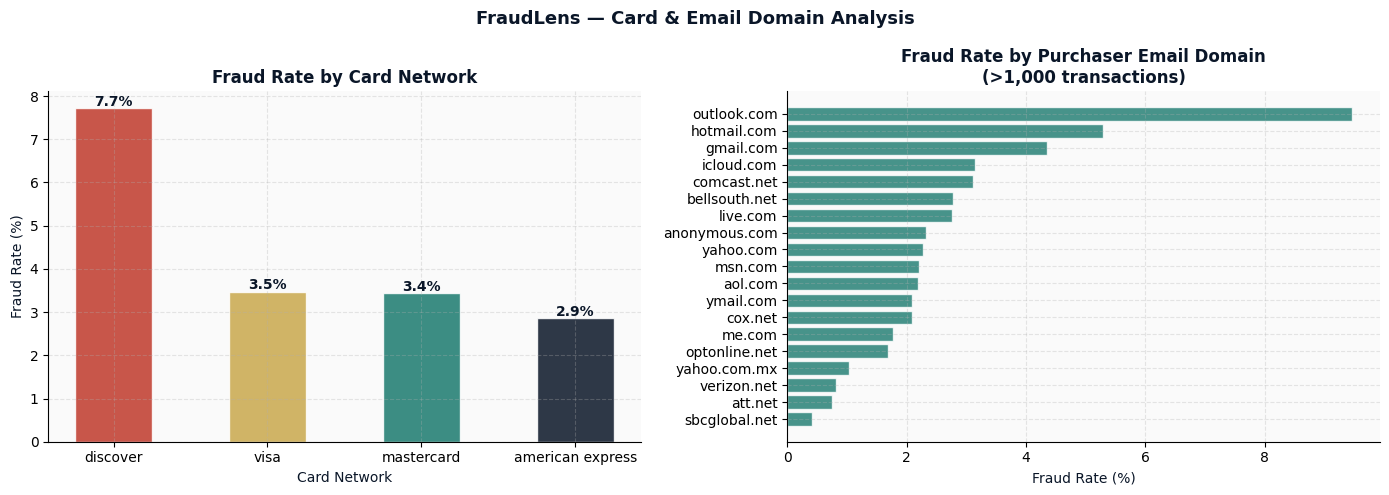

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FraudLens — Card & Email Domain Analysis',
             fontsize=13, fontweight='bold', color=NAVY)

# Card network fraud rate
card_fraud = df.groupby('card4')['isFraud'].agg(
    fraud_rate='mean', count='count').reset_index().dropna()
card_fraud = card_fraud.sort_values('fraud_rate', ascending=False)
card_fraud['fraud_rate'] *= 100

bars = axes[0].bar(card_fraud['card4'],
                   card_fraud['fraud_rate'],
                   color=[RED, GOLD, TEAL, NAVY][:len(card_fraud)],
                   alpha=0.85, edgecolor='white', width=0.5)
axes[0].set_title('Fraud Rate by Card Network',
                  color=NAVY, fontweight='bold')
axes[0].set_xlabel('Card Network', color=NAVY)
axes[0].set_ylabel('Fraud Rate (%)', color=NAVY)
for bar, val in zip(bars, card_fraud['fraud_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                f'{val:.1f}%', ha='center',
                fontsize=10, fontweight='bold', color=NAVY)

# Email domain fraud rate
email_fraud = df.groupby('P_emaildomain')['isFraud'].agg(
    fraud_rate='mean', count='count').reset_index().dropna()
email_fraud = email_fraud[email_fraud['count'] > 1000]
email_fraud = email_fraud.sort_values('fraud_rate', ascending=True)
email_fraud['fraud_rate'] *= 100

axes[1].barh(email_fraud['P_emaildomain'],
             email_fraud['fraud_rate'],
             color=TEAL, alpha=0.8, edgecolor='white')
axes[1].set_title('Fraud Rate by Purchaser Email Domain\n(>1,000 transactions)',
                  color=NAVY, fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)', color=NAVY)

plt.tight_layout()
plt.savefig('/content/04_card_email.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
import shutil

# Save all charts to Drive
charts_path = '/content/drive/MyDrive/fraudlens/outputs/charts/'
os.makedirs(charts_path, exist_ok=True)

for chart in ['01_overview.png', '02_time_patterns.png',
              '03_missing_values.png', '04_card_email.png']:
    shutil.copy(f'/content/{chart}', charts_path + chart)

print("✓ All charts saved to Google Drive")

print(f"""
╔══════════════════════════════════════════════════════════╗
║         FRAUDLENS — EDA SUMMARY                          ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Dataset: IEEE-CIS (Vesta Corporation)                   ║
║  Total transactions: {len(df):,}                         ║
║  Fraudulent: {df['isFraud'].sum():,} ({df['isFraud'].mean()*100:.2f}%)
║                                                          ║
║  KEY FINDINGS:                                           ║
║  1. 3.5% fraud rate — severe class imbalance             ║
║  2. Fraud peaks at night — minimal human review          ║
║  3. Identity features have 75%+ missing values           ║
║  4. Email domain is a strong fraud signal                ║
║  5. Amount distribution differs by fraud class           ║
║                                                          ║
║  NEXT: Feature engineering + model training              ║
╚══════════════════════════════════════════════════════════╝
""")

✓ All charts saved to Google Drive

╔══════════════════════════════════════════════════════════╗
║         FRAUDLENS — EDA SUMMARY                          ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Dataset: IEEE-CIS (Vesta Corporation)                   ║
║  Total transactions: 590,540                         ║
║  Fraudulent: 20,663 (3.50%)            
║                                                          ║
║  KEY FINDINGS:                                           ║
║  1. 3.5% fraud rate — severe class imbalance             ║
║  2. Fraud peaks at night — minimal human review          ║
║  3. Identity features have 75%+ missing values           ║
║  4. Email domain is a strong fraud signal                ║
║  5. Amount distribution differs by fraud class           ║
║                                                          ║
║  NEXT: Feature engineering + model training              ║
╚══════════